In [11]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from tqdm import tqdm, trange
from gulps.synthesis.gulps_decomposer import GulpsDecomposer
from gulps.viz.invariant_viz import render_path

In [6]:
from typing import List, Optional, Tuple

import numpy as np
from docplex.mp.dvar import Var
from docplex.mp.model import Model

from gulps.core.invariants import GateInvariants
from gulps.linear_program.qlr import len_qlr, qlr_inequalities


class BasicISAConstraints:
    """For sake of prototyping, assume sentence is known in advance."""

    _ci_block, _gi_block, _ciplus1_block, _bi = qlr_inequalities

    def __init__(
        self,
        invariant_sentence: List[GateInvariants],
    ):
        self.invariant_sentence = invariant_sentence
        self.N = len(invariant_sentence)
        self.model = self._create_model()
        self._target_def: Optional[np.ndarray] = None
        self._target_cts: List = []  # holds the 3 equality constraints for c_N

    def set_target(self, target_gate: GateInvariants, rho_bool: bool = False):
        if rho_bool:
            self._target_def = target_gate.rho_reflect().monodromy
        else:
            self._target_def = target_gate.monodromy

        # remove previous target constraints (if any), then add new ones
        if self._target_cts:
            self.model.remove_constraints(self._target_cts)
            self._target_cts.clear()

        # ci_nested represents [c2, ..., cN]; last element is cN
        self._target_cts = [
            self.model.add_constraint(
                self.ci_nested[-1][j] == float(self._target_def[j])
            )
            for j in range(3)
        ]

    def solve(self, log_output: bool = False):
        sol = self.model.solve(log_output=log_output)
        if not sol:
            return None, None, None

        gis = [
            np.array(
                [sol.get_value(self.gi_nested[i][j]) for j in range(3)], dtype=float
            )
            for i in range(self.N)
        ]
        cis = [
            np.array(
                [sol.get_value(self.ci_nested[i][j]) for j in range(3)], dtype=float
            )
            for i in range(self.N - 1)
        ]

        gi_list = [GateInvariants(tuple(g)) for g in gis]
        intermediate_invariants = (gi_list[0],) + tuple(
            GateInvariants(tuple(c)) for c in cis
        )

        return gi_list, intermediate_invariants

    def _create_model(self):
        m = Model("ISAConstraints", ignore_names=True)
        # Define variables, constraints, and objective here
        # STEP 1. CREATE ALL VARIABLES
        # Variables
        self.gi_nested = [
            m.continuous_var_list(3, lb=-1.0, ub=1.0) for _ in range(self.N)
        ]
        self.ci_nested = [
            m.continuous_var_list(3, lb=-1.0, ub=1.0) for _ in range(self.N - 1)
        ]

        # STEP 2. GATE PARAMETERIZATION + MONOTONIC
        for i in range(self.N):
            m.add_constraint(
                self.gi_nested[i][0] == self.invariant_sentence[i].monodromy[0]
            )
            m.add_constraint(
                self.gi_nested[i][1] == self.invariant_sentence[i].monodromy[1]
            )
            m.add_constraint(
                self.gi_nested[i][2] == self.invariant_sentence[i].monodromy[2]
            )

        # STEP 3. QLR CONSTRAINTS
        self._qlr_constraints(m)

        return m

    def _qlr_constraints(self, m: Model):
        # First block: L(g2, g1, c2)
        for r in range(len_qlr):
            m.add_constraint(
                m.scal_prod(self.gi_nested[1], self._ci_block[r])
                + m.scal_prod(self.gi_nested[0], self._gi_block[r])
                + m.scal_prod(self.ci_nested[0], self._ciplus1_block[r])
                <= float(self._bi[r])
            )

        # Interior blocks: L(c_j, g_{j+1}, c_{j+1})
        # ci_nested indexes: 0..N-2  -> (c2..cN)
        for j in range(1, self.N - 1):
            for r in range(len_qlr):
                m.add_constraint(
                    m.scal_prod(self.ci_nested[j - 1], self._ci_block[r])
                    + m.scal_prod(self.gi_nested[j + 1], self._gi_block[r])
                    + m.scal_prod(self.ci_nested[j], self._ciplus1_block[r])
                    <= float(self._bi[r])
                )

In [7]:
class EdgeISAConstraints:
    _ci_block, _gi_block, _ciplus1_block, _bi = qlr_inequalities

    def __init__(self, invariant_sentence: List[GateInvariants]):
        self.N = len(invariant_sentence)
        self._target_constraints: List = []  # holds the 3 equality constraints

        self.model = Model("ISAConstraints", ignore_names=True)
        self._invariant_sentence = invariant_sentence
        self.G = {
            i: np.asarray(gi.monodromy, dtype=np.float64)
            for i, gi in enumerate(invariant_sentence, start=1)
        }
        self.C = {
            i: self.model.continuous_var_list(3, lb=-1.0, ub=1.0)
            for i in range(2, self.N + 1)
        }

        # alias C1 = G1
        self.C[1] = self.G[1]

        for i in range(2, self.N + 1):
            self._add_qlr_edge(self.C[i - 1], self.G[i], self.C[i])

    def set_target(self, target_gate: GateInvariants, *, rho_bool: bool = False):
        T = target_gate.rho_reflect().monodromy if rho_bool else target_gate.monodromy
        T = np.asarray(T, dtype=np.float64)
        # add constaints that C_N = T
        if self._target_constraints:
            self.model.remove_constraints(self._target_constraints)
            self._target_constraints.clear()
        self._target_constraints = self.model.add_constraints(
            self.C[self.N][j] == T[j] for j in range(3)
        )

    def solve(self, log_output: bool = False):
        sol = self.model.solve(log_output=log_output)
        if not sol:
            return None, None, None

        cis = [
            np.array([sol.get_value(self.C[i][j]) for j in range(3)], dtype=float)
            for i in range(2, self.N + 1)
        ]

        intermediate_invariants = (self._invariant_sentence[0],) + tuple(
            GateInvariants(tuple(c)) for c in cis
        )

        return self._invariant_sentence, intermediate_invariants

    # FIXME for speed, avoid repeated calls
    def _add_qlr_edge(self, c_prev, g_const, c_next):
        """Enforce L(c_j, g_{j+1}, c_{j+1}) <= b row-wise."""
        for r in range(len_qlr):
            lhs = 0
            for x, y in zip(
                (c_prev, c_next, g_const),
                (self._ci_block[r], self._ciplus1_block[r], self._gi_block[r]),
            ):
                if isinstance(x, np.ndarray):
                    lhs += np.dot(x, y)
                elif isinstance(x[0], Var):
                    lhs += self.model.scal_prod(x, y)

            if isinstance(lhs, float):
                # all variables constant, evaluate directly
                assert lhs <= float(self._bi[r]), "Infeasible constraint detected."
            else:
                self.model.add_constraint(lhs <= float(self._bi[r]))

In [8]:
class ExtraEdgesISAConstraints(EdgeISAConstraints):
    B = np.array([np.float64(0.375), np.float64(0.125), np.float64(-0.125)])

    def __init__(self, invariant_sentence: List[GateInvariants]):
        super().__init__(invariant_sentence)

        # Add extra edges. We are going to introduce 2N-1 extra constraints
        # of the form L(Di, B, Ci) and L(Ci, B, Di+1) for Gi 1 to N-1
        # where Di is some unconstrained variable in the same manner as Ci
        # and D1 = B
        self.D = {
            i: self.model.continuous_var_list(3, lb=-1.0, ub=1.0)
            for i in range(2, self.N + 1)
        }

        # boundary condition D1 = B
        self.D[1] = self.B
        for i in range(1, self.N):
            self._add_qlr_edge(self.D[i], self.B, self.C[i])
            self._add_qlr_edge(self.C[i], self.B, self.D[i + 1])

    def solve(self):
        sol = self.model.solve()
        if not sol:
            return None, None, None

        cis = [
            np.array([sol.get_value(self.C[i][j]) for j in range(3)], dtype=float)
            for i in range(2, self.N + 1)
        ]

        dis = [
            np.array([sol.get_value(self.D[i][j]) for j in range(3)], dtype=float)
            for i in range(2, self.N + 1)
        ]

        intermediate_invariants = (self._invariant_sentence[0],) + tuple(
            GateInvariants(tuple(c)) for c in cis
        )

        full_intermediate_invariants = []
        # this should be (B, G1, D2, C2, ...)
        full_intermediate_invariants.append(GateInvariants(tuple(self.B)))
        full_intermediate_invariants.append(self._invariant_sentence[0])
        for i in range(2, self.N + 1):
            full_intermediate_invariants.append(GateInvariants(tuple(dis[i - 2])))
            full_intermediate_invariants.append(GateInvariants(tuple(cis[i - 2])))
        return (
            self._invariant_sentence,
            intermediate_invariants,
            full_intermediate_invariants,
        )

In [9]:
isa = [
    (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
]
gate_set, costs, names = zip(*isa)
decomposer = GulpsDecomposer(gate_set=gate_set, costs=costs, names=names)

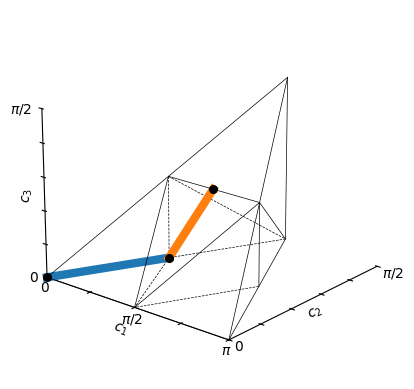

In [15]:
# u = random_unitary(4).data
# target = GateInvariants.from_unitary(SwapGate())
target = GateInvariants.from_weyl((0.5, 0.25, 0.25))
sentence_out, intermediates = decomposer._best_decomposition(target)
render_path(intermediates);

In [ ]:
# testing B.T.B type sentence
from tqdm import trange

for _ in trange(10_000):
    u = random_unitary(4).data
    target = GateInvariants.from_unitary(u)
    Binv = GateInvariants.from_weyl((0.5, 0.25, 0))
    sentence = [Binv, target, Binv]
    solver = BasicISAConstraints(sentence)
    solver.set_target(target)
    _, intermediates = solver.solve()
    if not intermediates:
        print("here")
        render_path(intermediates)

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 29/10000 [00:00<03:46, 43.98it/s]

In [ ]:
# %%timeit
# sentence_out, intermediates = decomposer._best_decomposition(
#     GateInvariants.from_unitary(random_unitary(4))
# )

<Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>

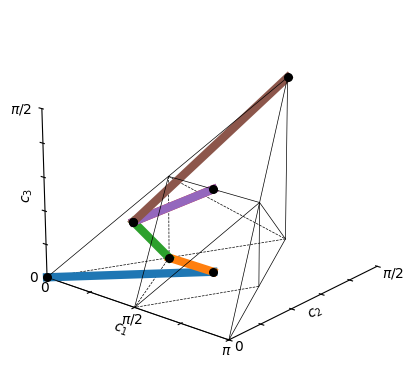

In [ ]:
solver = ExtraEdgesISAConstraints(sentence_out)
solver.set_target(GateInvariants.from_unitary(SwapGate()))
sentence_out, intermediate_invariants, extras = solver.solve()
from gulps.viz.invariant_viz import render_path

render_path(extras)

Version identifier: 22.1.2.0 | 2024-12-10 | f4cec290b
CPXPARAM_Read_DataCheck                          1
Tried aggregator 1 time.
LP Presolve eliminated 377 rows and 21 columns.
Reduced LP has 76 rows, 6 columns, and 258 nonzeros.
Presolve time = 0.00 sec. (0.23 ticks)

Iteration log . . .
Iteration:     1   Dual objective     =             0.000000


<Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>

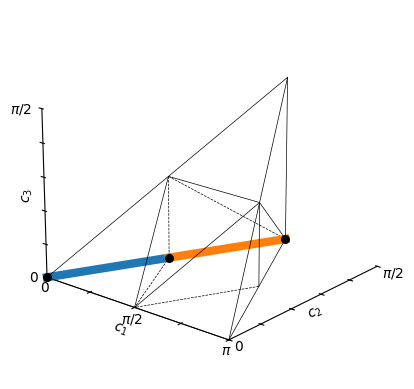

In [ ]:
solver = BGateDonorISAConstraints(sentence_out)
solver.set_target(target)
gi_list, intermediate_invariants, extras = solver.solve(log_output=True)
from gulps.viz.invariant_viz import render_path

render_path(intermediate_invariants)

[0.5  0.25 0.  ]
[0.25 0.25 0.  ]
[ 0.5   0.   -0.25]
[0.5 0.5 0. ]


<Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>

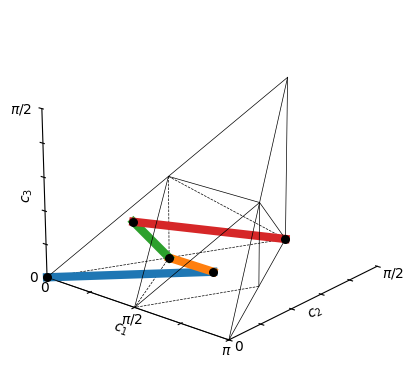

In [12]:
# want path from (Id, B, G1, D1, C2, D2, T)
induced_trajectory = [
    # GateInvariants(extras["Id"]),
    GateInvariants(extras["B"]),
    intermediate_invariants[0],
    GateInvariants(extras["D1"]),
    intermediate_invariants[1],
    # GateInvariants(extras["D2"]),
    # intermediate_invariants[2],
]
for ginv in induced_trajectory:
    print(ginv.weyl)
render_path(induced_trajectory)

In [ ]:
from gulps.synthesis.recover_equiv import recover_local_equivalence


def recover_equivalent_circuit(target_gate, current_gate):
    k1, k2, k3, k4, global_phase = recover_local_equivalence(target_gate, current_gate)
    temp = QuantumCircuit(2, global_phase=global_phase)
    temp.append(UnitaryGate(k1), [0])
    temp.append(UnitaryGate(k2), [1])
    temp.append(current_gate, [0, 1])
    temp.append(UnitaryGate(k3), [0])
    temp.append(UnitaryGate(k4), [1])
    return temp

In [60]:
class BGate(UnitaryGate):
    def __init__(self, theta=np.pi / 2):
        """BGate(theta) constructor."""
        c1 = np.cos(theta / 4)
        c3 = np.cos(3 * theta / 4)
        s1 = np.sin(theta / 4)
        s3 = np.sin(3 * theta / 4)
        return super().__init__(
            [
                [c1, 0, 0, 1j * s1],
                [0, c3, 1j * s3, 0],
                [0, 1j * s3, c3, 0],
                [1j * s1, 0, 0, c1],
            ],
            label="b",
        )


def b_sandwich(target, interior_only=False):
    # https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.93.020502
    c1, c2, c3 = np.pi * target.weyl / 2
    rb1 = 1 - 4 * np.sin(c2) ** 2 * np.cos(c3) ** 2
    b1 = np.arccos(rb1)
    rb2 = np.sqrt(
        np.cos(2 * c2) * np.cos(2 * c3) / (1 - 2 * np.sin(c2) ** 2 * np.cos(c3) ** 2)
    )
    b2 = np.arcsin(rb2)

    temp = QuantumCircuit(2)
    if interior_only:
        temp.ry(-2 * c1, 0)
        temp.rz(-b2, 1)
        temp.ry(-b1, 1)
        temp.rz(-b2, 1)
        return temp
    else:
        temp.append(BGate(), [0, 1])
        temp.ry(-2 * c1, 0)
        temp.rz(-b2, 1)
        temp.ry(-b1, 1)
        temp.rz(-b2, 1)
        temp.append(BGate(), [0, 1])
        return temp
        # return recover_equivalent_circuit(target.unitary, Operator(temp))

In [16]:
# u1 = b_sandwich(gi_list[0], interior_only=True)
# qc = QuantumCircuit(2)
# qc.append(BGate(), [0, 1])
# qc.compose(u1, inplace=True)
# qc.append(UnitaryGate(GateInvariants(extras["H1"]).unitary), [0, 1])
# qc.draw("mpl")
# GateInvariants.from_unitary(Operator(qc).data).plot()

In [33]:
GateInvariants.from_weyl((0.5, 0.25, 0)).makhlin

[3.081487911019576e-33, 0.0, 2.1584312461960072e-16]

[3.70736963e-01 1.47159685e-01 1.11022302e-16]


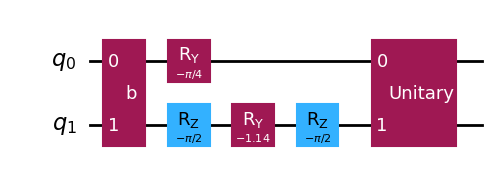

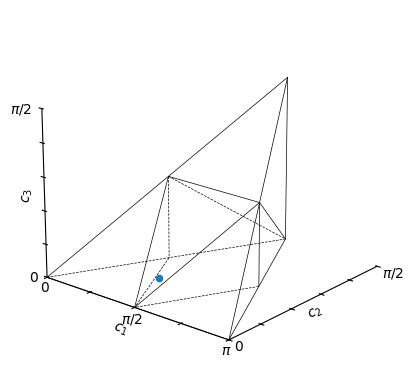

In [29]:
u1 = b_sandwich(gi_list[0], interior_only=True)
u2 = b_sandwich(GateInvariants(extras["H1"]), interior_only=True)
u3 = b_sandwich(gi_list[1], interior_only=True)

qc = QuantumCircuit(2)
qc.append(BGate(), [0, 1])
qc.compose(u1, inplace=True)
qc.append(UnitaryGate(GateInvariants(extras["H1"]).unitary), [0, 1])

gg = GateInvariants.from_unitary(Operator(qc).data)
gg.plot()
print(gg.weyl)
qc.draw("mpl")

[0.48679573 0.31786778 0.        ]


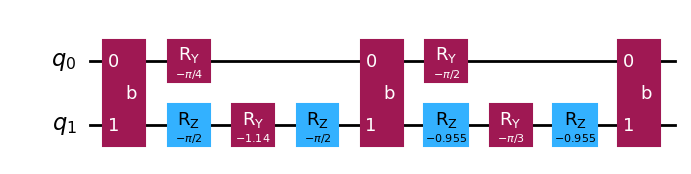

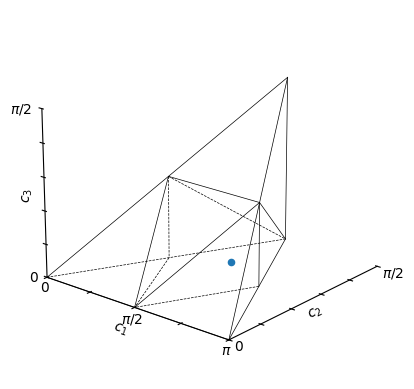

In [122]:
qc = QuantumCircuit(2)
qc.compose(b_sandwich(gi_list[0]), inplace=True)
qc.compose(b_sandwich(GateInvariants(extras["H1"]), interior_only=True), inplace=True)
# qc.compose(b_sandwich(gi_list[1]), inplace=True)
# qc.compose(b_sandwich(GateInvariants(extras["H2"]), interior_only=True), inplace=True)
# qc.compose(b_sandwich(gi_list[2]), inplace=True)
qc.append(BGate(), [0, 1])

gg = GateInvariants.from_unitary(Operator(qc).data)
gg.plot()
print(gg.weyl)
qc.draw("mpl")

(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>)

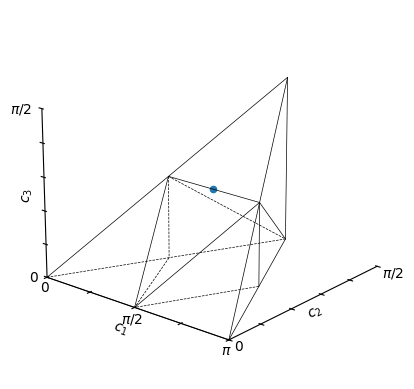

In [39]:
# to find the single-qubit gate layers we just need to b-sandwich decompose the Hs
GateInvariants(extras["H1"]).plot()